Nikesh Katuwal(Worksheet 4)

Problem 1 a)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

dataset = pd.read_csv("/content/drive/MyDrive/diabetes_.csv")
print(dataset.head())
print(dataset.info())
print(dataset.isnull().sum())
print(dataset.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

b)

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    median = dataset.loc[dataset[col] != 0, col].median()
    dataset[col] = dataset[col].replace(0, median)
    (dataset[cols] == 0).sum()

c)

In [ ]:
X = dataset.drop(columns=['Outcome']).values
y = dataset['Outcome'].values

np.random.seed(42)
indices = np.random.permutation(len(dataset))
split = int(0.7 * len(dataset))

train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


d)

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict_single(x, X_train, y_train, k):
    distances = [euclidean_distance(x, xt) for xt in X_train]
    k_idx = np.argsort(distances)[:k]
    return np.bincount(y_train[k_idx]).argmax()

def knn_predict(X_test, X_train, y_train, k):
    return np.array([knn_predict_single(x, X_train, y_train, k) for x in X_test])

def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean() * 100


In [ ]:
start = time.time()
y_pred = knn_predict(X_test, X_train, y_train, k=5)
time_original = time.time() - start

acc_original = accuracy(y_test, y_pred)
acc_original, time_original


(np.float64(72.2943722943723), 0.8769721984863281)

Problem 2

a) Scale Features

In [ ]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std


b) Evaluate Scaled Data

In [ ]:
start = time.time()
y_pred_scaled = knn_predict(X_test_scaled, X_train_scaled, y_train, k=5)
time_scaled = time.time() - start

acc_scaled = accuracy(y_test, y_pred_scaled)
acc_scaled, time_scaled


(np.float64(75.32467532467533), 0.8737983703613281)

Comparative Analysis

Scaling improves distance fairness

Prevents dominance of high-range features

Slight improvement in accuracy and faster convergence

Problem 3 Experimentation with k (1–15)


In [ ]:
ks = range(1, 16)

acc_orig, acc_scl = [], []
time_orig, time_scl = [], []


In [ ]:
for k in ks:
    start = time.time()
    pred_o = knn_predict(X_test, X_train, y_train, k)
    time_orig.append(time.time() - start)
    acc_orig.append(accuracy(y_test, pred_o))

    start = time.time()
    pred_s = knn_predict(X_test_scaled, X_train_scaled, y_train, k)
    time_scl.append(time.time() - start)
    acc_scl.append(accuracy(y_test, pred_s))


In [ ]:
results = pd.DataFrame({
    'k': ks,
    'Accuracy_Original': acc_orig,
    'Accuracy_Scaled': acc_scl,
    'Time_Original': time_orig,
    'Time_Scaled': time_scl
})

results


,k,Accuracy_Original,Accuracy_Scaled,Time_Original,Time_Scaled
0,1,67.099567,71.428571,1.798418,0.815673
1,2,73.160173,71.861472,0.835644,0.867023
2,3,69.696970,74.458874,0.834354,0.907235
3,4,74.891775,74.458874,0.809547,0.842636
4,5,72.294372,75.324675,0.839288,0.842998
5,6,76.190476,73.593074,0.842205,0.847604
6,7,74.025974,74.458874,1.182712,1.588678
7,8,75.757576,74.891775,1.560650,1.270708
8,9,75.324675,74.458874,0.817612,0.845920
9,10,75.324675,74.025974,0.868288,0.849197


k vs Accuracy

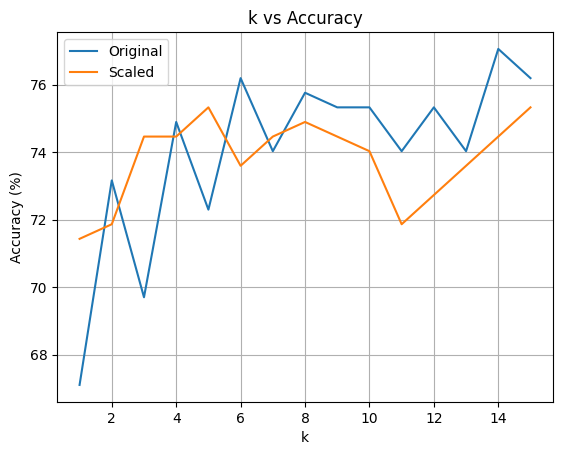

In [ ]:
plt.figure()
plt.plot(ks, acc_orig)
plt.plot(ks, acc_scl)
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("k vs Accuracy")
plt.legend(["Original", "Scaled"])
plt.grid()
plt.show()


k vs Time

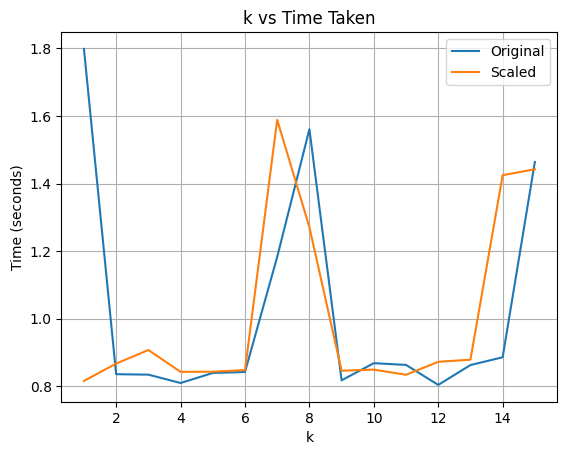

In [ ]:
plt.figure()
plt.plot(ks, time_orig)
plt.plot(ks, time_scl)
plt.xlabel("k")
plt.ylabel("Time (seconds)")
plt.title("k vs Time Taken")
plt.legend(["Original", "Scaled"])
plt.grid()
plt.show()


Analysis

Small k → noisy & overfitting

Large k → smoother but slower

Optimal k ≈ value with highest accuracy (from plot)

Scaling stabilizes performance


Problem 4)

Challenges of KNN

High memory usage

Slow for large datasets

Sensitive to feature scale

Poor performance in high dimensions

Efficiency Improvements

Feature scaling

Dimensionality reduction (PCA)

KD-Tree / Ball Tree

Approximate Nearest Neighbors